In [2]:
# 🧪 U-Net: End-to-End Demo (TensorFlow / Keras)

## 1) Install & imports

# If needed
# !pip install tensorflow matplotlib

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models


In [3]:
## 2) Create a tiny synthetic dataset (images + masks)

def generate_data(num_samples=200, img_size=64):
    X = np.zeros((num_samples, img_size, img_size, 1), dtype=np.float32)
    y = np.zeros((num_samples, img_size, img_size, 1), dtype=np.float32)

    for i in range(num_samples):
        radius = np.random.randint(5, 15)
        cx = np.random.randint(radius, img_size - radius)
        cy = np.random.randint(radius, img_size - radius)

        Y, X_grid = np.ogrid[:img_size, :img_size]
        dist = (X_grid - cx)**2 + (Y - cy)**2

        mask = dist <= radius**2
        y[i, mask, 0] = 1.0

        # add simple noise background
        X[i, :, :, 0] = np.random.rand(img_size, img_size) * 0.3
        X[i, mask, 0] += 0.7

    return X, y

X, y = generate_data(300)

# train-test split
X_train, X_test = X[:250], X[250:]
y_train, y_test = y[:250], y[250:]


In [12]:
# 300 images, 64x64 pixels, 1 channel (gray)

X.shape, y.shape

((300, 64, 64, 1), (300, 64, 64, 1))

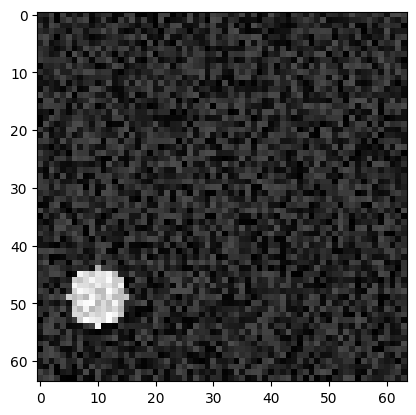

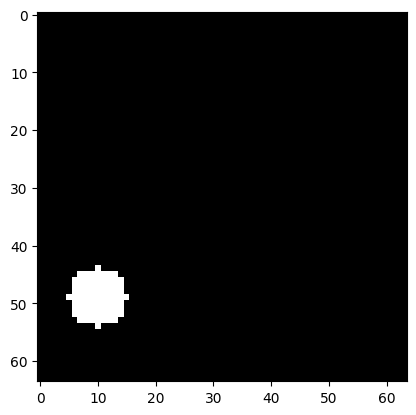

In [15]:
# 1) lets display first images and the target

plt.imshow(X[0].squeeze(), cmap="gray")
plt.show()

plt.imshow(y[0].squeeze(), cmap="gray")
plt.show()


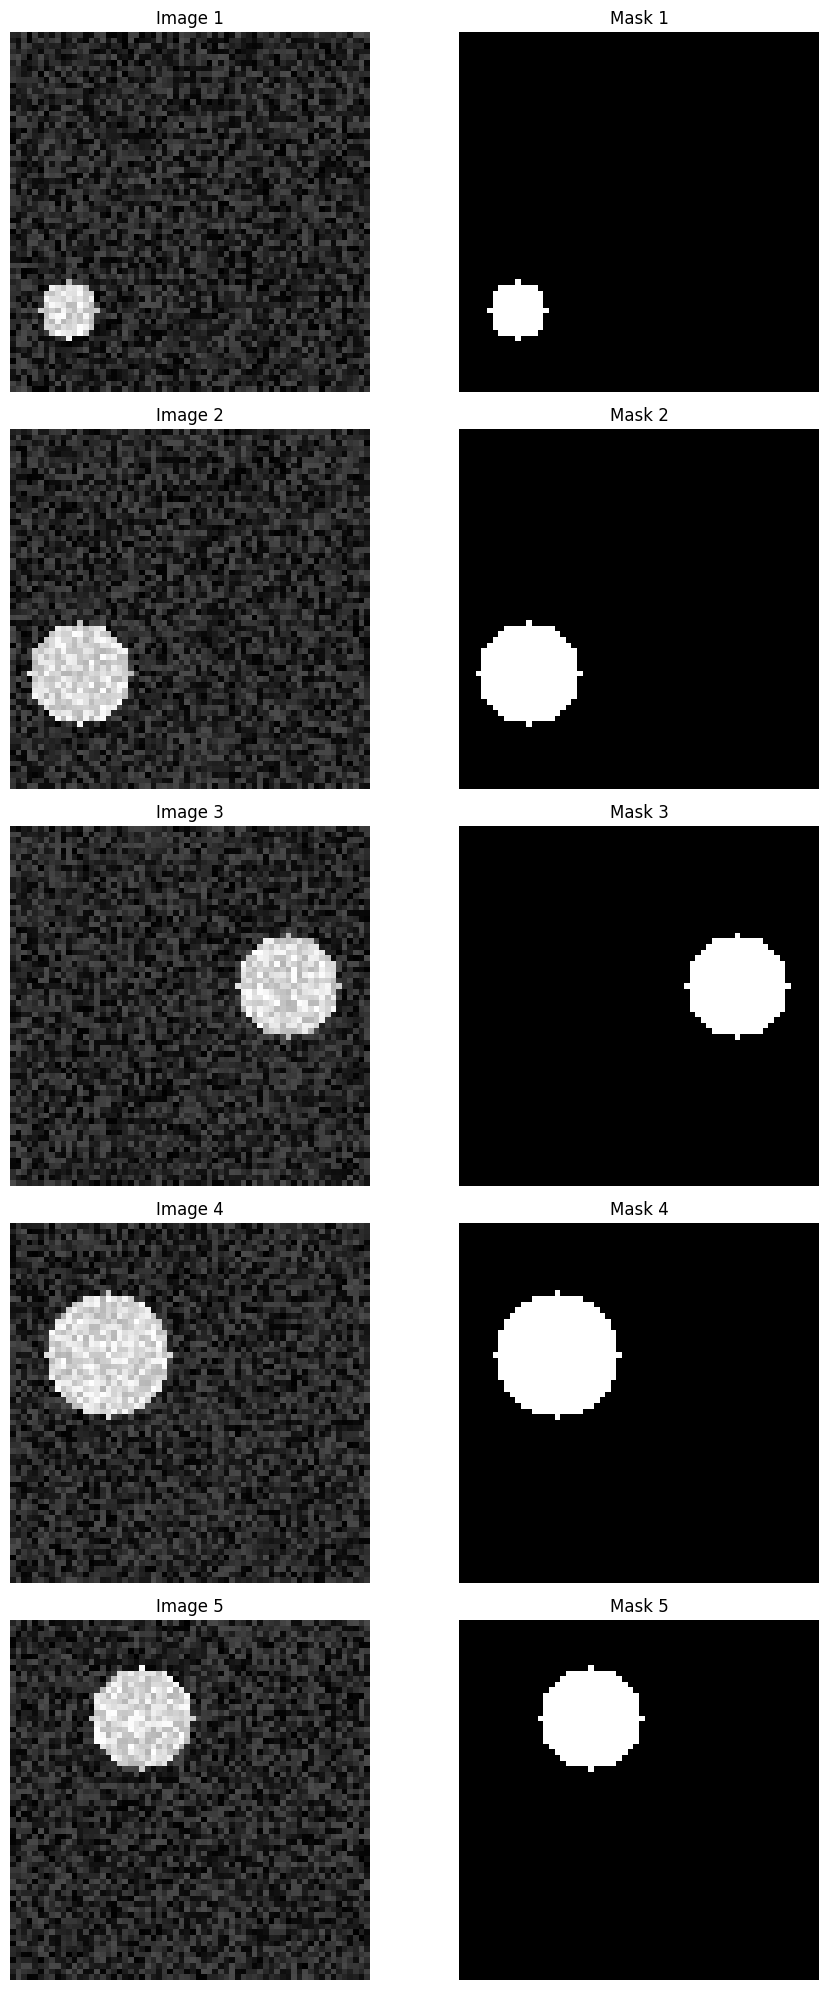

In [16]:
# 2) Lets display the first 5 images and their target mask next to each other

# Create a figure with 5 rows and 2 columns
fig, axes = plt.subplots(5, 2, figsize=(10, 20))

for i in range(5):
    # Display Original Image in the first column
    axes[i, 0].imshow(X[i].squeeze(), cmap="gray")
    axes[i, 0].set_title(f"Image {i+1}")
    axes[i, 0].axis("off") # Optional: hide axis ticks

    # Display Mask in the second column
    axes[i, 1].imshow(y[i].squeeze(), cmap="gray")
    axes[i, 1].set_title(f"Mask {i+1}")
    axes[i, 1].axis("off")

plt.tight_layout() # Adjusts spacing to prevent overlap
plt.show()


In [4]:
## 3) Build a simple U-Net

def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    return x

def build_unet(input_shape=(64, 64, 1)):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = conv_block(inputs, 16)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, 32)
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    b = conv_block(p2, 64)

    # Decoder
    u1 = layers.UpSampling2D()(b)
    u1 = layers.Concatenate()([u1, c2])
    c3 = conv_block(u1, 32)

    u2 = layers.UpSampling2D()(c3)
    u2 = layers.Concatenate()([u2, c1])
    c4 = conv_block(u2, 16)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(c4)

    model = models.Model(inputs, outputs)
    return model

model = build_unet()
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

model.summary()





Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 64, 64, 1)]          0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 64, 64, 16)           160       ['input_1[0][0]']             
                                                                                                  
 conv2d_1 (Conv2D)           (None, 64, 64, 16)           2320      ['conv2d[0][0]']              
                                                                                                  
 max_pooling2d (MaxPooling2  (None, 32, 32, 16)           0         ['conv2d_1[0][0]']            
 D)                                                                                        

In [5]:
## 4) Train

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=8
)


Epoch 1/5


32/32 [==============================] - 5s 65ms/step - loss: 0.3971 - accuracy: 0.8907 - val_loss: 0.1148 - val_accuracy: 0.9326
Epoch 2/5
32/32 [==============================] - 2s 50ms/step - loss: 0.0617 - accuracy: 0.9643 - val_loss: 0.0172 - val_accuracy: 0.9937
Epoch 3/5
32/32 [==============================] - 2s 52ms/step - loss: 0.0089 - accuracy: 0.9964 - val_loss: 0.0063 - val_accuracy: 0.9973
Epoch 4/5
32/32 [==============================] - 2s 52ms/step - loss: 0.0057 - accuracy: 0.9976 - val_loss: 0.0047 - val_accuracy: 0.9982
Epoch 5/5
32/32 [==============================] - 2s 49ms/step - loss: 0.0043 - accuracy: 0.9983 - val_loss: 0.0039 - val_accuracy: 0.9985


1/1 [==============================] - 0s 247ms/step


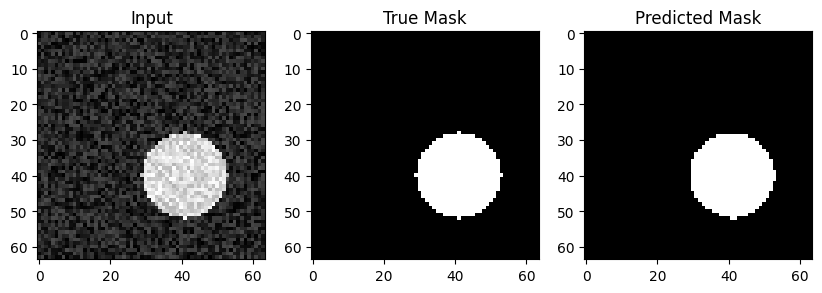

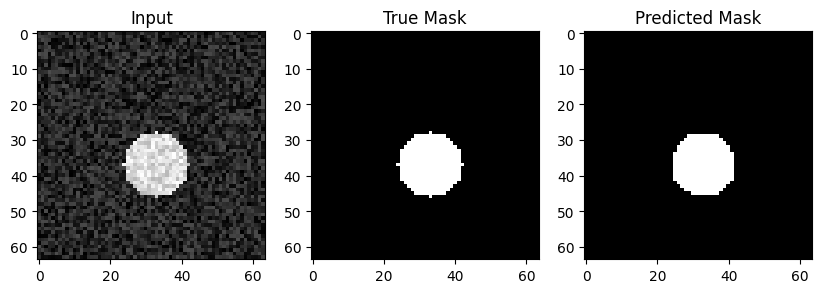

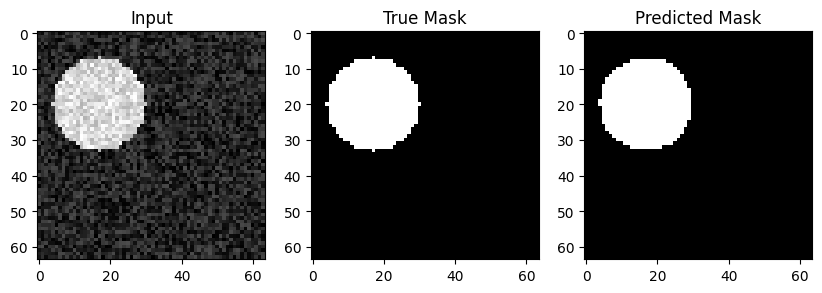

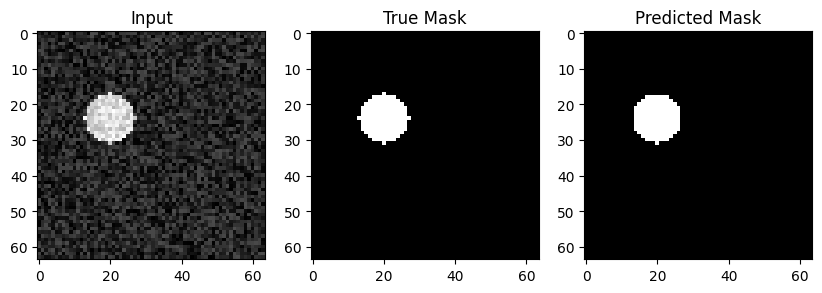

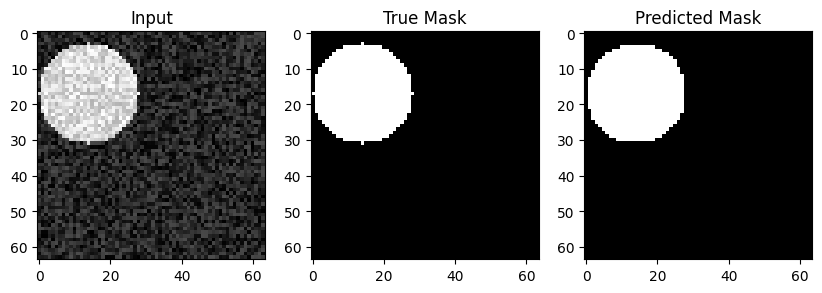

In [6]:
## 5) Predict & visualize

# predict on  first 5 images
preds = model.predict(X_test[:5])

def show_results(X, y_true, y_pred, n=5):
    for i in range(n):
        plt.figure(figsize=(10,3))

        plt.subplot(1,3,1)
        plt.title("Input")
        plt.imshow(X[i].squeeze(), cmap="gray")

        plt.subplot(1,3,2)
        plt.title("True Mask")
        plt.imshow(y_true[i].squeeze(), cmap="gray")

        plt.subplot(1,3,3)
        plt.title("Predicted Mask")
        plt.imshow(y_pred[i].squeeze() > 0.5, cmap="gray")

        plt.show()

show_results(X_test, y_test, preds)


In [ ]:

# 🧑‍🏫 Explain

* “We input an image → output is **pixel-wise classification**”
* “Encoder compresses → Decoder reconstructs”
* “Skip connections help recover details”

---

# 🎯 What Students Will Learn

* What segmentation means (pixel-level prediction)
* How **U-Net architecture works**
* Training vs inference
* Why skip connections matter


